In [ ]:
import pandas as pd
# Load the cleaned data
df = pd.read_csv("../Data/cleaned_lendingclub.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_default
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
3,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
4,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0


#1. Check Class Balance (Default vs Non-Default)

<Axes: title={'center': 'Class Distribution'}, xlabel='loan_default'>

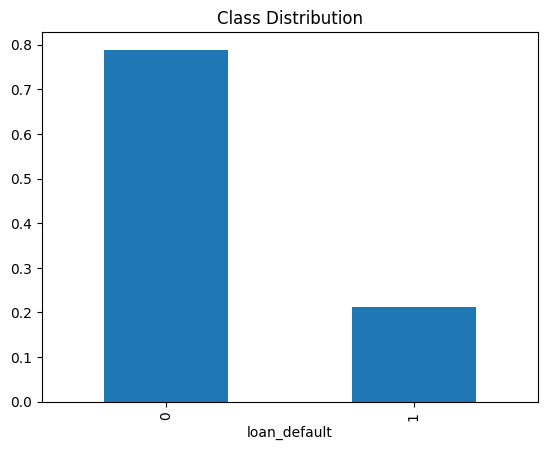

In [2]:
df['loan_default'].value_counts(normalize=True).plot(kind='bar', title='Class Distribution')

#2. Default Rate by Loan Grade

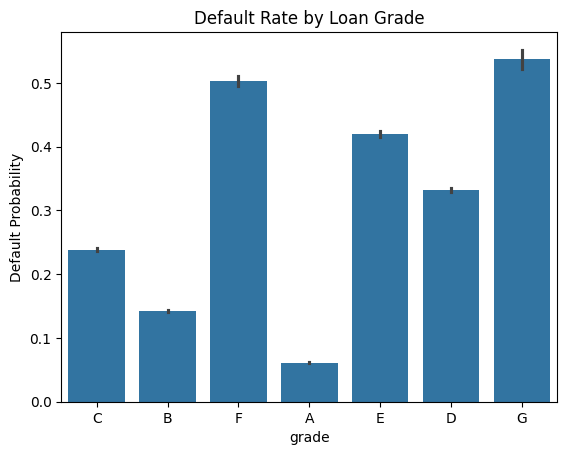

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='grade', y='loan_default', data=df)
plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Probability")
plt.show()

#3. Default Rate by Loan Purpose

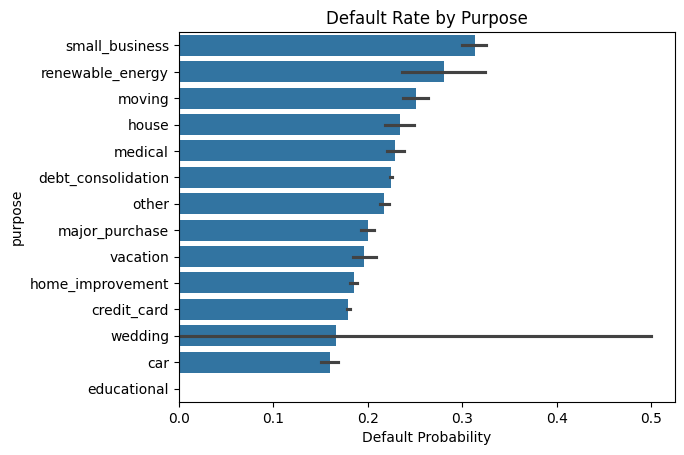

In [4]:
purpose_order = df.groupby('purpose')['loan_default'].mean().sort_values(ascending=False).index
sns.barplot(x='loan_default', y='purpose', data=df, order=purpose_order)
plt.title("Default Rate by Purpose")
plt.xlabel("Default Probability")
plt.show()

#4. Numerical Distributions: DTI, FICO, Annual Income

Text(0.5, 1.0, 'Log(Annual Income) by Default Status')

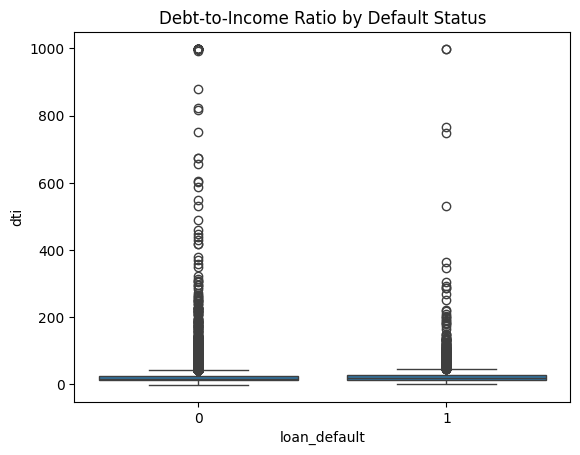

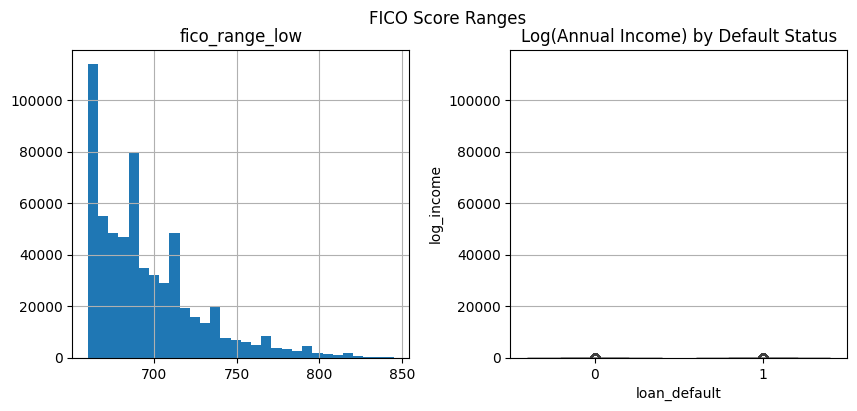

In [5]:
# DTI vs Default
sns.boxplot(x='loan_default', y='dti', data=df)
plt.title("Debt-to-Income Ratio by Default Status")

# FICO Score Distribution
df[['fico_range_low', 'fico_range_high']].hist(bins=30, figsize=(10,4))
plt.suptitle("FICO Score Ranges")

# Annual Income (Log-scaled to handle skew)
import numpy as np
df['log_income'] = np.log1p(df['annual_inc'])
sns.boxplot(x='loan_default', y='log_income', data=df)
plt.title("Log(Annual Income) by Default Status")

Text(0.5, 1.0, 'Log(Annual Income) by Default Status')

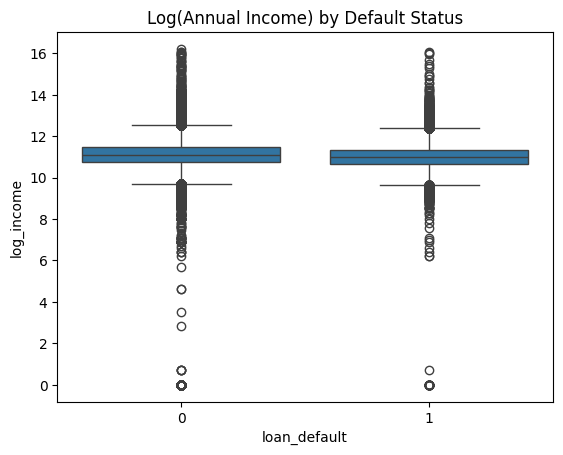

In [6]:
import numpy as np
df['log_income'] = np.log1p(df['annual_inc'])

sns.boxplot(x='loan_default', y='log_income', data=df)
plt.title("Log(Annual Income) by Default Status")